[Exercício 2] Custo Total (Com Penalizações de SLA): 5480.18 ms

RESULTADOS — ALGORITMO GENÉTICO
Melhor rota encontrada: [ 0 10  7  9  4  1  8  5  3  6  2 11]
Latência Total da rota: 237.95 ms
Perda de Pacotes Total da rota: 37.86 %
Penalidade SLA de Latência: 0.00
Penalidade de Segurança: 5000.00
Fitness final: 5137.91
Tempo de execução: 1687.38 ms


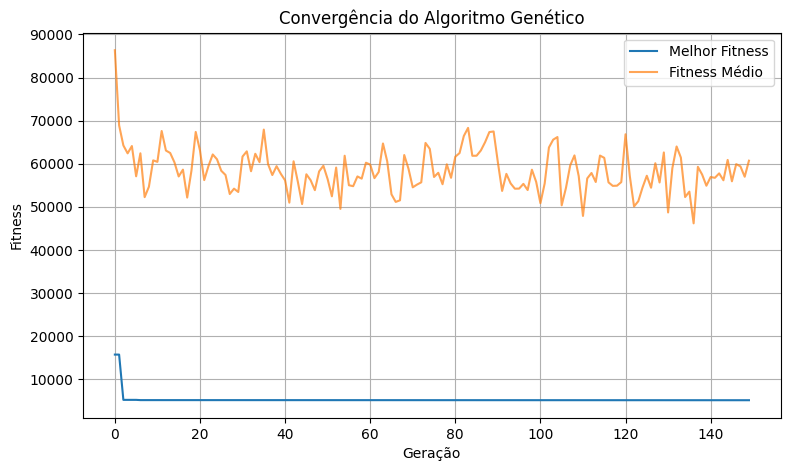

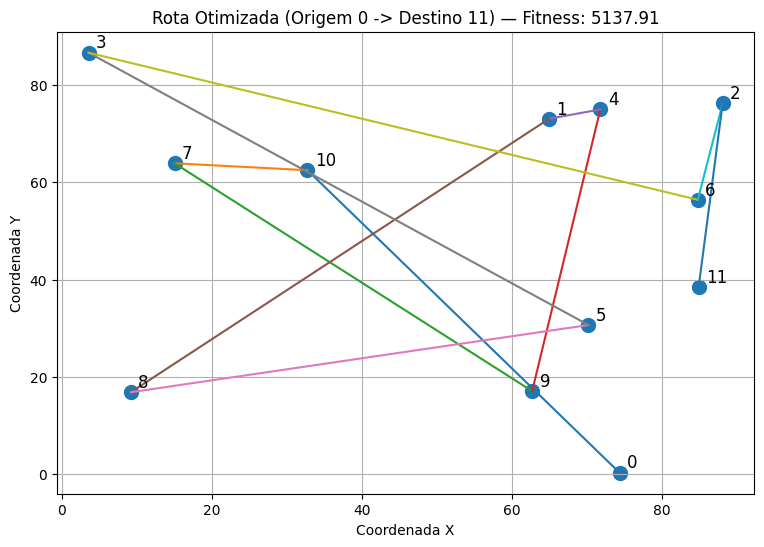

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================
# 1. CONFIGURAÇÕES DO PROBLEMA
# ============================================================

# Desenvolver o algoritmo de seleção de rota para um nó de comutação central
# em uma topologia contendo 12 roteadores (indexados de 0 a 11),
# com origem fixa no Nó 0 e destino no Nó 11.

NUM_NOS = 12 # Changed from 10 to 12
ORIGEM_NO = 0 # Fixed origin node
DESTINO_NO = 11 # Fixed destination node

# Configurar a amostragem estocástica com a semente np.random.seed(2026)
np.random.seed(2026);

# Cada enlace possui três parâmetros característicos:
# Latência ("ms"): Valor real positivo.
matriz_latencia_ms = np.random.uniform(5, 80, (NUM_NOS, NUM_NOS))

# Taxa de Perda de Pacotes (%): Valor real no intervalo [0,100].
matriz_perda_pacotes_percent = np.random.uniform(0, 10, (NUM_NOS, NUM_NOS))

# Índice de Reputação de Segurança (0" a " 100):
# Nós com índice <50 são considerados não confiáveis (risco de interceptação ou comprometimento).
reputacao_seguranca_nos = np.random.randint(0, 101, NUM_NOS)

TAMANHO_POPULACAO = 60
NUM_GERACOES = 150

TAXA_MUTACAO = 0.20

# Requisitos da Implementação:
# Implementar a função de fitness ponderada com penalização de segurança:
# "Fitness" (X)=w_1⋅"LatenciaTotal" (X)+w_2⋅"PerdaPacotesTotal" (X)+P_"Seguranca"
# em que P_"Seguranca" =5000 caso qualquer nó pertencente à rota apresente reputação <50.
W1 = 0.5 # Weight for LatenciaTotal
W2 = 0.5 # Weight for PerdaPacotesTotal
P_SEGURANCA_VALOR = 5000 # Penalty value for security

# Restrição simulada:
# nenhum enlace deve possuir distância superior a este valor
LIMITE_ENLACE = 50.0

# Penalização aplicada para cada violação (usada para LatenciaTotal e PerdaPacotesTotal)
PENALIDADE = 1000.0


# ============================================================
# 2. GERAÇÃO DOS NÓS
# ============================================================

# Cada nó possui uma posição X,Y
posicoes_nos = np.random.uniform(
    0,
    100,
    size=(NUM_NOS, 2) # Adjusted size to NUM_NOS
)


# ============================================================
# 3. MATRIZ DE DISTÂNCIAS (Matriz de Coordenadas, não latência)
# ============================================================

def gerar_matriz_coord_euclidiana(posicoes):
    """
    Calcula a distância euclidiana entre todos os pares de nós.
    """

    num_nos = len(posicoes)

    matriz = np.zeros((num_nos, num_nos))

    for i in range(num_nos):
        for j in range(num_nos):

            diferenca = posicoes[i] - posicoes[j]

            matriz[i, j] = np.linalg.norm(diferenca)

    return matriz


matriz_coord_euclidiana = gerar_matriz_coord_euclidiana(posicoes_nos)


# ============================================================
# 4. FUNÇÃO DE CUSTO DA ROTA (COM SLA - Latência)
# ============================================================

def calcular_custo_com_sla_latencia(rota, matriz_latencia, limite_sla=50.0):
    custo_total = 0.0; penalidade = 0.0
    """
    Calcula o custo total de latência de uma rota (origem a destino) com penalização SLA.
    """

    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]

        latencia_enlace = matriz_latencia[origem, destino]
        custo_total += latencia_enlace

        if latencia_enlace > limite_sla:
            penalidade += 1000.0 # PENALIDADE global para SLA

    return custo_total + penalidade

# User's added exercise code - adapted for 12 nodes, fixed origin and destination
rota_teste_exercicio = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
custo_final_exercicio = calcular_custo_com_sla_latencia(rota_teste_exercicio, matriz_latencia_ms)
print(f"[Exercício 2] Custo Total (Com Penalizações de SLA): {custo_final_exercicio:.2f} ms")


# ============================================================
# 4.1. FUNÇÃO DE CUSTO DA ROTA (BASE - Latência)
# ============================================================

def calcular_latencia_total_rota(rota, matriz_latencia):
    """
    Calcula o custo total de latência de uma rota (origem a destino) sem penalidades SLA.
    """
    custo = 0.0
    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        custo += matriz_latencia[origem, destino]
    return custo


# ============================================================
# 4.2. FUNÇÃO DE CUSTO DA ROTA (BASE - Perda de Pacotes)
# ============================================================

def calcular_perda_pacotes_total_rota(rota, matriz_perda_pacotes):
    """
    Calcula a perda total de pacotes de uma rota (origem a destino).
    """
    perda = 0.0
    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        perda += matriz_perda_pacotes[origem, destino]
    return perda


# ============================================================
# 5. FUNÇÃO DE PENALIZAÇÃO (Latência)
# ============================================================

def calcular_penalidade_latencia(rota, matriz_latencia, limite_enlace, penalidade_valor):
    """
    Aplica penalização quando algum enlace de latência da rota
    ultrapassa o limite permitido.
    """

    total_penalidade = 0.0

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        latencia = matriz_latencia[origem, destino]

        if latencia > limite_enlace:

            violacao = latencia - limite_enlace
            total_penalidade += penalidade_valor * violacao # Using global PENALIDADE constant

    return total_penalidade


# ============================================================
# 5.1. FUNÇÃO DE PENALIZAÇÃO (Segurança)
# ============================================================

def calcular_penalidade_seguranca(rota, reputacao_seguranca_nos, p_seguranca_valor=5000):
    """
    Aplica penalização se qualquer nó na rota tiver reputação de segurança < 50.
    """
    for no in rota:
        if reputacao_seguranca_nos[no] < 50:
            return p_seguranca_valor
    return 0


# ============================================================
# 6. FUNÇÃO FITNESS
# ============================================================

def calcular_fitness(
    rota,
    matriz_latencia_ms,
    matriz_perda_pacotes_percent,
    reputacao_seguranca_nos,
    w1, w2, p_seguranca_valor,
    limite_enlace, penalidade_latencia_valor
):
    """
    Fitness = w1 * LatenciaTotal + w2 * PerdaPacotesTotal + P_Seguranca

    Como estamos minimizando o problema,
    quanto menor o fitness, melhor.
    """

    latencia_total = calcular_latencia_total_rota(rota, matriz_latencia_ms)
    perda_pacotes_total = calcular_perda_pacotes_total_rota(rota, matriz_perda_pacotes_percent)
    penalidade_seguranca = calcular_penalidade_seguranca(rota, reputacao_seguranca_nos, p_seguranca_valor)

    # Add additional penalties for latency if desired (re-using old PENALIDADE mechanism)
    penalidade_latencia_sla = calcular_penalidade_latencia(rota, matriz_latencia_ms, limite_enlace, penalidade_latencia_valor)

    fitness = (
        w1 * latencia_total +
        w2 * perda_pacotes_total +
        penalidade_seguranca +
        penalidade_latencia_sla
    )

    return fitness


# ============================================================
# 7. CROSSOVER OX
# ============================================================

def crossover_ox(pai1, pai2, origem=0, destino=11): # Added origin and destination parameters
    """
    Ordered Crossover (OX).

    Preserva a validade da permutação dos nós intermediários.
    """

    # Extract the intermediate parts (nodes between origin and destination)
    intermediate_pai1 = pai1[1:-1]
    intermediate_pai2 = pai2[1:-1]
    intermediate_len = len(intermediate_pai1)

    # If there are no intermediate nodes, or only one, crossover doesn't make sense or is trivial
    if intermediate_len <= 1:
        return pai1.copy()

    filho_intermediate = np.full(intermediate_len, -1, dtype=int)

    ponto1, ponto2 = sorted(
        np.random.choice(intermediate_len, 2, replace=False)
    )

    filho_intermediate[ponto1:ponto2] = intermediate_pai1[ponto1:ponto2]

    posicao = ponto2
    for elemento in intermediate_pai2:
        if elemento not in filho_intermediate:
            if posicao >= intermediate_len:
                posicao = 0
            filho_intermediate[posicao] = elemento
            posicao += 1

    # Reconstruct the full route for the child
    return np.array([origem] + list(filho_intermediate) + [destino])


# ============================================================
# 8. MUTAÇÃO SWAP
# ============================================================

def mutacao_swap(rota, taxa_mutacao, origem=0, destino=11): # Added origin and destination parameters
    """
    Troca aleatoriamente duas posições dos nós intermediários da rota.
    """

    rota_copy = rota.copy()
    intermediate_segment = rota_copy[1:-1]
    intermediate_len = len(intermediate_segment)

    if np.random.rand() < taxa_mutacao and intermediate_len >= 2: # Need at least 2 intermediate nodes to swap
        idx1, idx2 = np.random.choice(intermediate_len, 2, replace=False)
        intermediate_segment[idx1], intermediate_segment[idx2] = \
            intermediate_segment[idx2], intermediate_segment[idx1]

    return np.array([origem] + list(intermediate_segment) + [destino])


# ============================================================
# 9. SELEÇÃO POR TORNEIO
# ============================================================

def selecao_torneio(populacao, fitness, tamanho_torneio=2):
    """
    Seleciona um indivíduo através de um torneio.

    Como estamos minimizando:
    menor fitness = vencedor.
    """

    participantes = np.random.choice(
        len(populacao),
        tamanho_torneio,
        replace=False
    )

    melhor = participantes[
        np.argmin(
            [fitness[i] for i in participantes]
        )
    ]

    return populacao[melhor]


# ============================================================
# 10. CRIAÇÃO DA POPULAÇÃO INICIAL
# ============================================================

def criar_populacao(tamanho_populacao, num_nos, origem=0, destino=11): # Added origin and destination parameters
    populacao = []
    # Intermediate nodes are all nodes except origin and destination
    intermediate_nodes = [node for node in range(num_nos) if node != origem and node != destino]
    for _ in range(tamanho_populacao):
        np.random.shuffle(intermediate_nodes)
        route = [origem] + intermediate_nodes + [destino]
        populacao.append(np.array(route))
    return populacao


populacao = criar_populacao(
    TAMANHO_POPULACAO,
    NUM_NOS,
    ORIGEM_NO,
    DESTINO_NO # Passed origin and destination
)


# ============================================================
# 11. HISTÓRICO DA EVOLUÇÃO
# ============================================================

historico_melhor = []
historico_medio = []


# Melhor solução global
melhor_rota_global = None
melhor_fitness_global = np.inf


# ============================================================
# 12. EXECUÇÃO DO ALGORITMO GENÉTICO
# ============================================================

tempo_inicio = time.time()


for geracao in range(NUM_GERACOES):

    # --------------------------------------------------------
    # Avaliação da população
    # --------------------------------------------------------

    fitness_populacao = [
        calcular_fitness(
            individuo,
            matriz_latencia_ms,
            matriz_perda_pacotes_percent,
            reputacao_seguranca_nos,
            W1, W2, P_SEGURANCA_VALOR,
            LIMITE_ENLACE, PENALIDADE
        )
        for individuo in populacao
    ]

    # --------------------------------------------------------
    # Melhor indivíduo da geração
    # --------------------------------------------------------

    indice_melhor = np.argmin(
        fitness_populacao
    )

    melhor_rota_geracao = (
        populacao[indice_melhor].copy()
    )

    melhor_fitness_geracao = (
        fitness_populacao[indice_melhor]
    )

    # --------------------------------------------------------
    # Atualização do melhor indivíduo global
    # --------------------------------------------------------

    if melhor_fitness_geracao < melhor_fitness_global:

        melhor_fitness_global = (
            melhor_fitness_geracao
        )

        melhor_rota_global = (
            melhor_rota_geracao.copy()
        )

    # --------------------------------------------------------
    # Histórico
    # --------------------------------------------------------

    historico_melhor.append(
        melhor_fitness_global
    )

    historico_medio.append(
        np.mean(fitness_populacao)
    )

    # --------------------------------------------------------
    # Elitismo
    # --------------------------------------------------------

    nova_populacao = [
        melhor_rota_global.copy()
    ]

    # --------------------------------------------------------
    # Reprodução
    # --------------------------------------------------------

    while len(nova_populacao) < TAMANHO_POPULACAO:

        # Seleção
        pai1 = selecao_torneio(
            populacao,
            fitness_populacao
        )

        pai2 = selecao_torneio(
            populacao,
            fitness_populacao
        )

        # Crossover
        filho = crossover_ox(
            pai1,
            pai2,
            ORIGEM_NO,
            DESTINO_NO # Passed origin and destination
        )

        # Mutação
        filho = mutacao_swap(
            filho,
            TAXA_MUTACAO,
            ORIGEM_NO,
            DESTINO_NO # Passed origin and destination
        )

        # Inserção na nova população
        nova_populacao.append(
            filho
        )

    # --------------------------------------------------------
    # Substituição da população
    # --------------------------------------------------------

    populacao = nova_populacao


tempo_fim = time.time()


# ============================================================
# 13. AVALIAÇÃO DA SOLUÇÃO FINAL
# ============================================================

latencia_total_final = calcular_latencia_total_rota(
    melhor_rota_global,
    matriz_latencia_ms
)

perda_pacotes_total_final = calcular_perda_pacotes_total_rota(
    melhor_rota_global,
    matriz_perda_pacotes_percent
)

penalidade_latencia_sla_final = calcular_penalidade_latencia(
    melhor_rota_global,
    matriz_latencia_ms,
    LIMITE_ENLACE,
    PENALIDADE
)

penalidade_seguranca_final = calcular_penalidade_seguranca(
    melhor_rota_global,
    reputacao_seguranca_nos,
    P_SEGURANCA_VALOR
)

fitness_final = (
    W1 * latencia_total_final +
    W2 * perda_pacotes_total_final +
    penalidade_seguranca_final +
    penalidade_latencia_sla_final
)


tempo_execucao = (
    tempo_fim - tempo_inicio
) * 1000


# ============================================================
# 14. RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("RESULTADOS — ALGORITMO GENÉTICO")
print("=" * 60)

print(
    f"Melhor rota encontrada: "
    f"{melhor_rota_global}"
)

print(
    f"Latência Total da rota: "
    f"{latencia_total_final:.2f} ms"
)

print(
    f"Perda de Pacotes Total da rota: "
    f"{perda_pacotes_total_final:.2f} %"
)

print(
    f"Penalidade SLA de Latência: "
    f"{penalidade_latencia_sla_final:.2f}"
)

print(
    f"Penalidade de Segurança: "
    f"{penalidade_seguranca_final:.2f}"
)

print(
    f"Fitness final: "
    f"{fitness_final:.2f}"
)

print(
    f"Tempo de execução: "
    f"{tempo_execucao:.2f} ms"
)

print("=" * 60)


# ============================================================
# 15. GRÁFICO DE CONVERGÊNCIA
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    historico_melhor,
    label="Melhor Fitness"
)

plt.plot(
    historico_medio,
    label="Fitness Médio",
    alpha=0.7
)

plt.title(
    "Convergência do Algoritmo Genético"
)

plt.xlabel("Geração")

plt.ylabel("Fitness")

plt.grid(True)

plt.legend()

plt.show()


# ============================================================
# 16. VISUALIZAÇÃO DA ROTA
# ============================================================

plt.figure(figsize=(9, 6))

# Desenha os nós
plt.scatter(
    posicoes_nos[:, 0],
    posicoes_nos[:, 1],
    s=100
)

# Identificação dos nós
for i, (x, y) in enumerate(posicoes_nos):

    plt.text(
        x + 1,
        y + 1,
        str(i),
        fontsize=12
    )


# Desenha a rota (from origin to destination)
for i in range(len(melhor_rota_global) - 1): # Changed loop to represent an open route

    origem = melhor_rota_global[i]

    destino = melhor_rota_global[i + 1] # Changed to i + 1


    plt.plot(
        [
            posicoes_nos[origem, 0],
            posicoes_nos[destino, 0]
        ],
        [
            posicoes_nos[origem, 1],
            posicoes_nos[destino, 1]
        ]
    )


plt.title(
    f"Rota Otimizada (Origem {ORIGEM_NO} -> Destino {DESTINO_NO}) — " # Updated title
    f"Fitness: {fitness_final:.2f}"
)

plt.xlabel("Coordenada X")

plt.ylabel("Coordenada Y")

plt.grid(True)

plt.show()